# FairLens — Notebook 1: Model Training & Saving
**Purpose:** Train the Random Forest classifier, tune the threshold, and save everything to disk.  
Notebook 2 (FairLens Layer) will load these files — it never retrains the model.

---
### Protected attributes tracked
| Attribute | Type | Groups |
|-----------|------|--------|
| `gender` | Binary | Male / Female |
| `ever_married` | Binary | Yes / No |
| `Residence_type` | Binary | Urban / Rural |
| `age_group` | Binned (3) | <40 / 40–60 / 60+ |

### What this notebook saves
| File | Contents |
|------|----------|
| `rf_model.pkl` | Trained + calibrated Random Forest |
| `config.json` | Threshold, feature names, label maps, protected attr metadata |
| `X_test.npy` / `y_test.npy` | Test set (20%) — sealed until NB2 |
| `X_train.npy` / `y_train.npy` | Train set (70%) — pre-SMOTE, real patients only, for RL |
| `X_val.npy` / `y_val.npy` | Val set (10%) — used for recall floor in RL |
| `{split}_{attr}.npy` | Protected attr arrays for all 3 splits × 4 attributes = 12 files |

> **Run all cells top to bottom. After the final cell you will see a save confirmation.**

## STAGE 1 — Install & Import

In [1]:
import subprocess, sys
pkgs = ["kagglehub","pandas","numpy","matplotlib","seaborn",
        "scikit-learn","imbalanced-learn"]
print("Installing packages...")
r = subprocess.run([sys.executable,"-m","pip","install","--quiet"]+pkgs,
                   capture_output=True, text=True)
print("Done." if r.returncode==0 else r.stderr[-400:])

Installing packages...
Done.


In [2]:
import os, json, warnings, random
import numpy  as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import kagglehub

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.metrics         import (
    confusion_matrix, roc_auc_score, recall_score,
    f1_score, precision_score, average_precision_score)
from imblearn.over_sampling  import SMOTE
from imblearn.combine        import SMOTETomek
from imblearn.under_sampling import TomekLinks

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

SAVE_DIR = "fairlens_assets"
os.makedirs(SAVE_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi":120, "axes.spines.top":False,
    "axes.spines.right":False, "font.family":"DejaVu Sans",
    "axes.titlesize":12, "axes.labelsize":11, "axes.titleweight":"bold"})

C_POS="#E05C97"; C_NEG="#4A90D9"; C_GOOD="#2E7D32"
print("Imports OK.")
print(f"Assets will be saved to: {SAVE_DIR}")

c:\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK.
Assets will be saved to: fairlens_assets


## STAGE 2 — Load & Explore Data

In [3]:
print("Downloading dataset from Kaggle...")
try:
    path     = kagglehub.dataset_download(
                   "shashwatwork/cerebral-stroke-predictionimbalaced-dataset")
    csv_path = os.path.join(path, "dataset.csv")
    print(f"Downloaded: {csv_path}")
except Exception as e:
    csv_path = "/content/dataset.csv"
    print(f"Kaggle failed ({e}). Trying {csv_path}")

df_raw = pd.read_csv(csv_path)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(df_raw.head(3).to_string())

Downloaded: C:\Users\Shaleen\.cache\kagglehub\datasets\shashwatwork\cerebral-stroke-predictionimbalaced-dataset\versions\1\dataset.csv
Shape: 43,400 rows x 12 columns
      id  gender   age  hypertension  heart_disease ever_married work_type Residence_type  avg_glucose_level   bmi smoking_status  stroke
0  30669    Male   3.0             0              0           No  children          Rural              95.12  18.0            NaN       0
1  30468    Male  58.0             1              0          Yes   Private          Urban              87.96  39.2   never smoked       0
2  16523  Female   8.0             0              0           No   Private          Urban             110.89  17.6            NaN       0


CLASS DISTRIBUTION
  No Stroke: 42,617  (98.2%)  #####################################################
  Stroke   :    783  (1.8%)  
  Imbalance ratio: 54.4:1

PROTECTED ATTRIBUTE x STROKE (raw data)

  gender:
        Total  Strokes      Rate  Rate_pct
gender                                    
Female  25665      431  0.016793      1.68
Male    17724      352  0.019860      1.99
Other      11        0  0.000000      0.00

  ever_married:
              Total  Strokes      Rate  Rate_pct
ever_married                                    
No            15462       80  0.005174      0.52
Yes           27938      703  0.025163      2.52

  Residence_type:
                Total  Strokes      Rate  Rate_pct
Residence_type                                    
Rural           21644      384  0.017742      1.77
Urban           21756      399  0.018340      1.83

  age_group (binned):
               Total  Strokes      Rate  Rate_pct
age_group_raw                                    
<40            

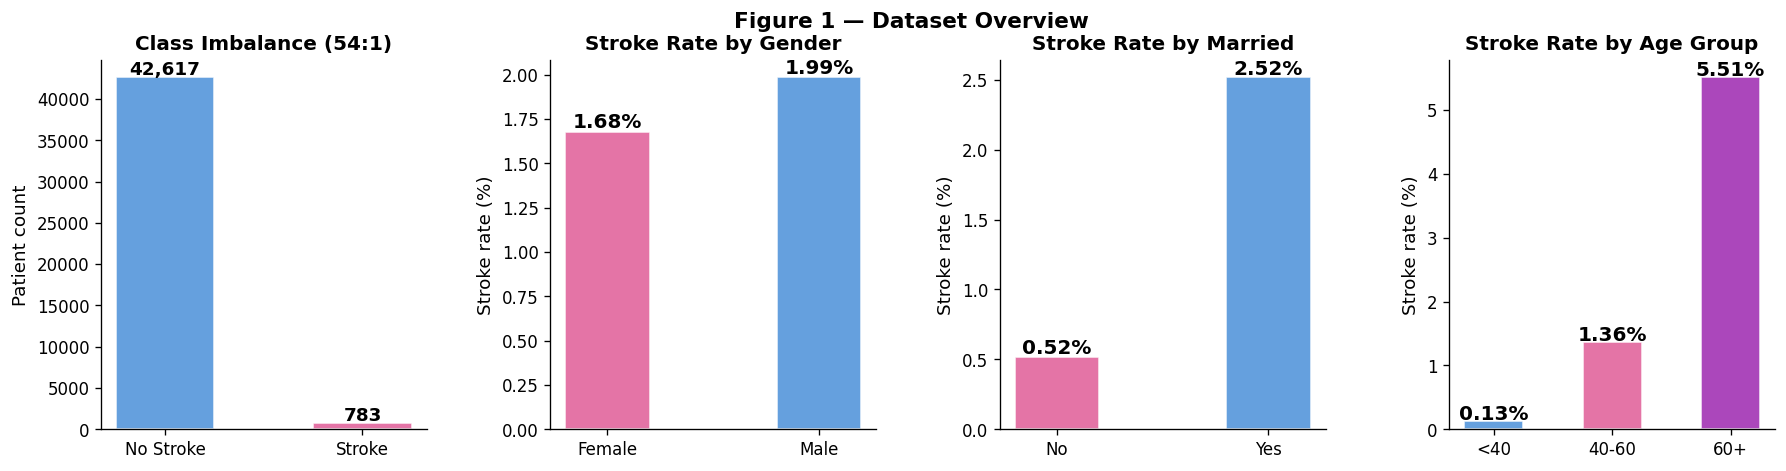

Figure 1 saved.


In [4]:
vc = df_raw["stroke"].value_counts().sort_index()
imbalance_ratio = vc[0] / vc[1]

print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)
for k,v in vc.items():
    label = "Stroke   " if k==1 else "No Stroke"
    bar   = "#" * int(v/800)
    print(f"  {label}: {v:6,}  ({v/len(df_raw)*100:.1f}%)  {bar}")
print(f"  Imbalance ratio: {imbalance_ratio:.1f}:1")

# Protected attribute summaries
print("\n" + "=" * 60)
print("PROTECTED ATTRIBUTE x STROKE (raw data)")
print("=" * 60)
for col in ["gender", "ever_married", "Residence_type"]:
    gs = df_raw.groupby(col)["stroke"].agg(["count","sum","mean"])
    gs.columns = ["Total","Strokes","Rate"]
    gs["Rate_pct"] = (gs["Rate"]*100).round(2)
    print(f"\n  {col}:")
    print(gs.to_string())

# Age bins preview
df_raw["age_group_raw"] = pd.cut(df_raw["age"], bins=[0,40,60,120],
                                  labels=["<40","40-60","60+"])
gs_age = df_raw.groupby("age_group_raw", observed=True)["stroke"].agg(["count","sum","mean"])
gs_age.columns = ["Total","Strokes","Rate"]
gs_age["Rate_pct"] = (gs_age["Rate"]*100).round(2)
print("\n  age_group (binned):")
print(gs_age.to_string())

# Figure 1: Dataset overview
fig = plt.figure(figsize=(18,4))
fig.suptitle("Figure 1 — Dataset Overview", fontweight="bold", fontsize=13)
gs_fig = gridspec.GridSpec(1,4, figure=fig, wspace=0.38)

ax1 = fig.add_subplot(gs_fig[0])
ax1.bar(["No Stroke","Stroke"], [vc[0],vc[1]],
        color=[C_NEG,C_POS], alpha=0.85, edgecolor="white", width=0.5)
ax1.set_title("Class Imbalance (54:1)")
ax1.set_ylabel("Patient count")
for i,v in enumerate([vc[0],vc[1]]):
    ax1.text(i, v+300, f"{v:,}", ha="center", fontsize=11, fontweight="bold")

ax2 = fig.add_subplot(gs_fig[1])
glist = [g for g in df_raw[df_raw["gender"].isin(["Male","Female"])]["gender"].unique()]
gs_g  = df_raw[df_raw["gender"].isin(["Male","Female"])].groupby("gender")["stroke"].mean()
rlist = [gs_g.get(g,0)*100 for g in ["Female","Male"]]
clist = [C_POS, C_NEG]
bars  = ax2.bar(["Female","Male"], rlist, color=clist, alpha=0.85, edgecolor="white", width=0.4)
ax2.set_title("Stroke Rate by Gender")
ax2.set_ylabel("Stroke rate (%)")
for bar,v in zip(bars,rlist):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f"{v:.2f}%", ha="center", fontsize=12, fontweight="bold")

ax3 = fig.add_subplot(gs_fig[2])
gs_m  = df_raw.groupby("ever_married")["stroke"].mean()*100
ax3.bar(gs_m.index, gs_m.values, color=[C_POS,C_NEG], alpha=0.85, edgecolor="white", width=0.4)
ax3.set_title("Stroke Rate by Married")
ax3.set_ylabel("Stroke rate (%)")
for i,(k,v) in enumerate(gs_m.items()):
    ax3.text(i, v+0.02, f"{v:.2f}%", ha="center", fontsize=12, fontweight="bold")

ax4 = fig.add_subplot(gs_fig[3])
age_labels = ["<40","40-60","60+"]
age_rates  = [gs_age.loc[l,"Rate_pct"] if l in gs_age.index else 0 for l in age_labels]
ax4.bar(age_labels, age_rates, color=[C_NEG,C_POS,"#9C27B0"], alpha=0.85, edgecolor="white", width=0.5)
ax4.set_title("Stroke Rate by Age Group")
ax4.set_ylabel("Stroke rate (%)")
for i,v in enumerate(age_rates):
    ax4.text(i, v+0.02, f"{v:.2f}%", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/fig1_eda.png", bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

## STAGE 3 — Preprocess + Feature Engineering

In [5]:
df = df_raw.copy()
df.drop(columns=["id"], inplace=True)
df = df[df["gender"].isin(["Male","Female"])].copy()
print(f"Rows after removing 'Other' gender: {len(df):,}")

df["bmi"].fillna(df["bmi"].median(), inplace=True)
df["smoking_status"].fillna("Unknown", inplace=True)
print(f"Missing values remaining: {df.isnull().sum().sum()}")

# ── Age binning BEFORE label encoding (age is raw float here) ──────────────
# Bins: 0 = under 40, 1 = 40-60, 2 = 60+
df["age_group"] = pd.cut(df["age"],
                          bins=[0, 40, 60, 120],
                          labels=[0, 1, 2]).astype(int)
age_group_labels = {0: "<40", 1: "40-60", 2: "60+"}
print(f"Age group distribution:")
for k,v in age_group_labels.items():
    n = (df["age_group"]==k).sum()
    pos = ((df["age_group"]==k) & (df["stroke"]==1)).sum()
    print(f"  {v}: {n:,} patients  strokes={pos}  rate={pos/n:.3f}")

# ── Label-encode categoricals ──────────────────────────────────────────────
cat_cols = ["gender","ever_married","work_type","Residence_type","smoking_status"]
le_dict  = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Build label maps for protected attributes (code -> human label)
def make_label_map(le):
    return {int(le.transform([c])[0]): c for c in le.classes_}

gender_labels        = make_label_map(le_dict["gender"])
married_labels       = make_label_map(le_dict["ever_married"])
residence_labels     = make_label_map(le_dict["Residence_type"])
# age_group_labels already defined above (int->str)

print(f"\nGender encoding      : {gender_labels}")
print(f"Married encoding     : {married_labels}")
print(f"Residence encoding   : {residence_labels}")
print(f"Age group encoding   : {age_group_labels}")

# ── Interaction features ───────────────────────────────────────────────────
df["age_glucose"]  = df["age"] * df["avg_glucose_level"]
df["age_bmi"]      = df["age"] * df["bmi"]
df["hypert_heart"] = df["hypertension"] * df["heart_disease"]
df["age_hypert"]   = df["age"] * df["hypertension"]
df["glucose_bmi"]  = df["avg_glucose_level"] * df["bmi"]

feature_cols = [c for c in df.columns if c not in ["stroke", "age_group_raw"]]
X = df[feature_cols]
y = df["stroke"]
print(f"\nFeature matrix : {X.shape}")
print(f"Features       : {feature_cols}")
print(f"Positives      : {y.sum()} ({y.mean()*100:.2f}%)")

Rows after removing 'Other' gender: 43,389
Missing values remaining: 0
Age group distribution:
  <40: 19,751 patients  strokes=25  rate=0.001
  40-60: 13,127 patients  strokes=179  rate=0.014
  60+: 10,511 patients  strokes=579  rate=0.055

Gender encoding      : {0: 'Female', 1: 'Male'}
Married encoding     : {0: 'No', 1: 'Yes'}
Residence encoding   : {0: 'Rural', 1: 'Urban'}
Age group encoding   : {0: '<40', 1: '40-60', 2: '60+'}

Feature matrix : (43389, 16)
Features       : ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'age_group', 'age_glucose', 'age_bmi', 'hypert_heart', 'age_hypert', 'glucose_bmi']
Positives      : 783 (1.80%)


## STAGE 4 — Stratified 3-Way Split

**Split contract:**
| Split | Size | Purpose |
|-------|------|---------|
| **TRAIN (70%)** | ~34k | SMOTETomek resampling → model fit. Pre-SMOTE real-patient copy → RL agent training |
| **VAL (10%)** | ~4.8k | Threshold tuning (F2) + recall floor for RL penalty |
| **TEST (20%)** | ~9.7k | Final evaluation only — sealed until Notebook 2 |

Protected attribute arrays are extracted from each split **before** SMOTE so they reflect real patient distribution.

In [6]:
# ── 70/10/20 stratified split ─────────────────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=RANDOM_STATE)
# 0.125 of 80% = 10% of total

print("Split summary:")
for name, ys in [("TRAIN",y_train),("VAL",y_val),("TEST",y_test)]:
    n, pos = len(ys), int(ys.sum())
    print(f"  {name:<6} -> {n:6,} samples  |  stroke: {pos}  ({pos/n*100:.1f}%)")

# ── Extract protected attribute arrays for ALL 3 splits ───────────────────
# These are extracted now, before SMOTE destroys the patient identity.
PROTECTED_ATTRS = ["gender", "ever_married", "Residence_type", "age_group"]

split_attrs = {}
for split_name, X_split in [("train", X_train), ("val", X_val), ("test", X_test)]:
    split_attrs[split_name] = {}
    for attr in PROTECTED_ATTRS:
        split_attrs[split_name][attr] = X_split[attr].values.copy()

# Convenience references (used in later stages)
train_gender    = split_attrs["train"]["gender"]
val_gender      = split_attrs["val"]["gender"]
test_gender     = split_attrs["test"]["gender"]

# ── Convert to numpy arrays ───────────────────────────────────────────────
X_train_arr = X_train.values; X_val_arr = X_val.values; X_test_arr = X_test.values
y_train_arr = y_train.values; y_val_arr  = y_val.values; y_test_arr  = y_test.values

print(f"\nGender encoding : {gender_labels}")
print(f"Test gender     : {dict(zip(*np.unique(test_gender, return_counts=True)))}")

print("\nProtected attribute distributions per split:")
attr_lbl_maps = {
    "gender":         gender_labels,
    "ever_married":   married_labels,
    "Residence_type": residence_labels,
    "age_group":      age_group_labels,
}
for attr in PROTECTED_ATTRS:
    lmap = attr_lbl_maps[attr]
    print(f"  {attr}:")
    for split_name in ["train","val","test"]:
        arr = split_attrs[split_name][attr]
        dist = {lmap.get(int(g), str(g)): int((arr==g).sum())
                for g in np.unique(arr)}
        print(f"    {split_name:<6}: {dist}")

print("\nTest set is now SEALED — not used again in this notebook.")

Split summary:
  TRAIN  -> 30,372 samples  |  stroke: 548  (1.8%)
  VAL    ->  4,339 samples  |  stroke: 78  (1.8%)
  TEST   ->  8,678 samples  |  stroke: 157  (1.8%)

Gender encoding : {0: 'Female', 1: 'Male'}
Test gender     : {np.int64(0): np.int64(5149), np.int64(1): np.int64(3529)}

Protected attribute distributions per split:
  gender:
    train : {'Female': 18000, 'Male': 12372}
    val   : {'Female': 2516, 'Male': 1823}
    test  : {'Female': 5149, 'Male': 3529}
  ever_married:
    train : {'No': 10796, 'Yes': 19576}
    val   : {'No': 1573, 'Yes': 2766}
    test  : {'No': 3087, 'Yes': 5591}
  Residence_type:
    train : {'Rural': 15104, 'Urban': 15268}
    val   : {'Rural': 2187, 'Urban': 2152}
    test  : {'Rural': 4347, 'Urban': 4331}
  age_group:
    train : {'<40': 13797, '40-60': 9223, '60+': 7352}
    val   : {'<40': 1978, '40-60': 1292, '60+': 1069}
    test  : {'<40': 3976, '40-60': 2612, '60+': 2090}

Test set is now SEALED — not used again in this notebook.


## STAGE 5 — SMOTETomek Resampling

Applied **only to training set**. Val and test remain real-world distribution.  
Protected attribute arrays were already extracted pre-SMOTE — they are preserved.

In [7]:
print("Applying SMOTETomek to training set only...")
print(f"  Before -> class 0: {(y_train_arr==0).sum():,}  class 1: {(y_train_arr==1).sum():,}")

smotetomek = SMOTETomek(
    smote=SMOTE(random_state=RANDOM_STATE, k_neighbors=5),
    tomek=TomekLinks(sampling_strategy="majority"),
    random_state=RANDOM_STATE)
X_train_res, y_train_res = smotetomek.fit_resample(X_train_arr, y_train_arr)

print(f"  After  -> class 0: {(y_train_res==0).sum():,}  class 1: {(y_train_res==1).sum():,}")
print(f"  Total training samples after SMOTETomek: {len(y_train_res):,}")
print()
print("  NOTE: X_train_arr / y_train_arr (pre-SMOTE) are saved for RL.")
print("        X_train_res / y_train_res (post-SMOTE) are used for model training only.")
print("SMOTETomek complete.")

Applying SMOTETomek to training set only...
  Before -> class 0: 29,824  class 1: 548
  After  -> class 0: 29,530  class 1: 29,824
  Total training samples after SMOTETomek: 59,354

  NOTE: X_train_arr / y_train_arr (pre-SMOTE) are saved for RL.
        X_train_res / y_train_res (post-SMOTE) are used for model training only.
SMOTETomek complete.


## STAGE 6 — Train Calibrated Random Forest

In [8]:
print("Training Random Forest (this takes ~1-2 minutes)...")

rf_base = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 15,
    min_samples_leaf = 4,
    max_features     = "sqrt",
    class_weight     = "balanced",
    random_state     = RANDOM_STATE,
    n_jobs           = -1)

# Calibrate probabilities — critical for threshold sensitivity in Notebook 2
rf = CalibratedClassifierCV(rf_base, method="isotonic", cv=3)
rf.fit(X_train_res, y_train_res)
print("Model trained and calibrated.")

proba_val  = rf.predict_proba(X_val_arr)[:,  1]
proba_test = rf.predict_proba(X_test_arr)[:, 1]
print(f"Val  proba range : [{proba_val.min():.3f}, {proba_val.max():.3f}]")
print(f"Test proba range : [{proba_test.min():.3f}, {proba_test.max():.3f}]")

Training Random Forest (this takes ~1-2 minutes)...
Model trained and calibrated.
Val  proba range : [0.000, 0.947]
Test proba range : [0.000, 0.971]


## STAGE 7 — Tune Decision Threshold on Val Set

Using **F2-score** (weights recall 2× precision) — correct for healthcare (54:1 imbalance).  
Accuracy is NOT used as primary metric due to severe class imbalance.

In [9]:
def fbeta_score(y_true, y_pred, beta=2.0):
    tp=int(((y_pred==1)&(y_true==1)).sum())
    fp=int(((y_pred==1)&(y_true==0)).sum())
    fn=int(((y_pred==0)&(y_true==1)).sum())
    p=tp/(tp+fp+1e-9); r=tp/(tp+fn+1e-9); b2=beta**2
    return (1+b2)*p*r/(b2*p+r+1e-9)

def gmean_score(y_true, y_pred):
    cm=confusion_matrix(y_true,y_pred); tn,fp,fn,tp=cm.ravel()
    return np.sqrt((tp/(tp+fn+1e-9))*(tn/(tn+fp+1e-9)))

# ── Threshold search on VAL set ───────────────────────────────────────────
thresholds = np.arange(0.05, 0.70, 0.005)
best_thresh = 0.5; best_f2 = 0.0

for t in thresholds:
    yp = (proba_val>=t).astype(int)
    f2 = fbeta_score(y_val_arr, yp, beta=2.0)
    if f2 > best_f2:
        best_f2, best_thresh = f2, t

print(f"Best threshold (val set F2): {best_thresh:.3f}  |  F2={best_f2:.4f}")

# ── Evaluate on TEST set (base model, no correction) ─────────────────────
y_pred_base    = (proba_test >= best_thresh).astype(int)
recall_base    = recall_score(y_test_arr, y_pred_base, pos_label=1)
precision_base = precision_score(y_test_arr, y_pred_base, pos_label=1, zero_division=0)
f1_base        = f1_score(y_test_arr, y_pred_base, pos_label=1)
f2_base        = fbeta_score(y_test_arr, y_pred_base, beta=2.0)
gmean_base     = gmean_score(y_test_arr, y_pred_base)
roc_base       = roc_auc_score(y_test_arr, proba_test)
ap_base        = average_precision_score(y_test_arr, proba_test)
cm_base        = confusion_matrix(y_test_arr, y_pred_base)
tn_b,fp_b,fn_b,tp_b = cm_base.ravel()

print("\nBase model performance on TEST set:")
print(f"  Recall      : {recall_base:.4f}  (caught {tp_b} of {tp_b+fn_b} real strokes)")
print(f"  Precision   : {precision_base:.4f}")
print(f"  F1-stroke   : {f1_base:.4f}")
print(f"  F2-stroke   : {f2_base:.4f}  <- primary metric (recall-weighted)")
print(f"  G-Mean      : {gmean_base:.4f}")
print(f"  ROC-AUC     : {roc_base:.4f}")
print(f"  Avg Prec    : {ap_base:.4f}")
print(f"  NOTE: Accuracy is omitted — meaningless at {imbalance_ratio:.0f}:1 imbalance")

Best threshold (val set F2): 0.060  |  F2=0.1783

Base model performance on TEST set:
  Recall      : 0.2994  (caught 47 of 157 real strokes)
  Precision   : 0.0649
  F1-stroke   : 0.1067
  F2-stroke   : 0.1738  <- primary metric (recall-weighted)
  G-Mean      : 0.5250
  ROC-AUC     : 0.7999
  Avg Prec    : 0.0599
  NOTE: Accuracy is omitted — meaningless at 54:1 imbalance


## STAGE 8 — Save Everything to Disk

In [10]:
# ── 1. Save trained model ─────────────────────────────────────────────────
model_path = f"{SAVE_DIR}/rf_model.pkl"
joblib.dump(rf, model_path)
print(f"Model saved      -> {model_path}")

# ── 2. Save config ────────────────────────────────────────────────────────
config = {
    "best_threshold"    : float(best_thresh),
    "imbalance_ratio"   : float(imbalance_ratio),
    "feature_cols"      : feature_cols,
    "fairness_threshold": 0.05,
    "random_state"      : RANDOM_STATE,
    # Protected attributes
    "protected_attrs"   : PROTECTED_ATTRS,
    "attr_label_maps"   : {
        "gender"        : {str(k):v for k,v in gender_labels.items()},
        "ever_married"  : {str(k):v for k,v in married_labels.items()},
        "Residence_type": {str(k):v for k,v in residence_labels.items()},
        "age_group"     : {str(k):v for k,v in age_group_labels.items()},
    },
    # Column indices in feature_cols (used for quick lookup in NB2)
    "attr_col_idx"      : {attr: feature_cols.index(attr) for attr in PROTECTED_ATTRS},
    # Base model metrics (reference for NB2 before/after comparison)
    "base_metrics": {
        "recall"   : float(recall_base),
        "precision": float(precision_base),
        "f1"       : float(f1_base),
        "f2"       : float(f2_base),
        "gmean"    : float(gmean_base),
        "roc_auc"  : float(roc_base),
        "tp"       : int(tp_b),
        "fp"       : int(fp_b),
        "fn"       : int(fn_b),
        "tn"       : int(tn_b),
    }
}
config_path = f"{SAVE_DIR}/config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print(f"Config saved     -> {config_path}")

# ── 3. Save feature arrays (3 splits) ────────────────────────────────────
for arr, name in [
    (X_train_arr, "X_train"), (y_train_arr, "y_train"),   # pre-SMOTE for RL
    (X_val_arr,   "X_val"),   (y_val_arr,   "y_val"),
    (X_test_arr,  "X_test"),  (y_test_arr,  "y_test"),
]:
    np.save(f"{SAVE_DIR}/{name}.npy", arr)

# ── 4. Save protected attribute arrays (3 splits × 4 attrs = 12 files) ───
for split_name in ["train", "val", "test"]:
    for attr in PROTECTED_ATTRS:
        arr  = split_attrs[split_name][attr]
        path = f"{SAVE_DIR}/{split_name}_{attr}.npy"
        np.save(path, arr)

print(f"Arrays saved     -> {SAVE_DIR}/  (6 feature arrays + 12 attribute arrays)")

# ── 5. Confirm everything is there ───────────────────────────────────────
print("\n" + "=" * 58)
print("SAVED FILES")
print("=" * 58)
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f"  {fname:<38} {size:8.1f} KB")
print("=" * 58)
print("\nNotebook 1 complete.")
print(f"Open Notebook 2 and set ASSET_DIR = '{SAVE_DIR}'")

Model saved      -> fairlens_assets/rf_model.pkl
Config saved     -> fairlens_assets/config.json
Arrays saved     -> fairlens_assets/  (6 feature arrays + 12 attribute arrays)

SAVED FILES
  X_test.npy                               1084.9 KB
  X_train.npy                              3796.6 KB
  X_val.npy                                 542.5 KB
  config.json                                 1.3 KB
  fig1_eda.png                               60.5 KB
  rf_model.pkl                            89835.3 KB
  test_Residence_type.npy                    67.9 KB
  test_age_group.npy                         67.9 KB
  test_ever_married.npy                      67.9 KB
  test_gender.npy                            67.9 KB
  train_Residence_type.npy                  237.4 KB
  train_age_group.npy                       237.4 KB
  train_ever_married.npy                    237.4 KB
  train_gender.npy                          237.4 KB
  val_Residence_type.npy                     34.0 KB
  val_age_group.